β₀ (intercept) = 4.0967
β₁ (slope)     = 2.8883

After gradient descent:
β₀ = 4.0967
β₁ = 2.8883


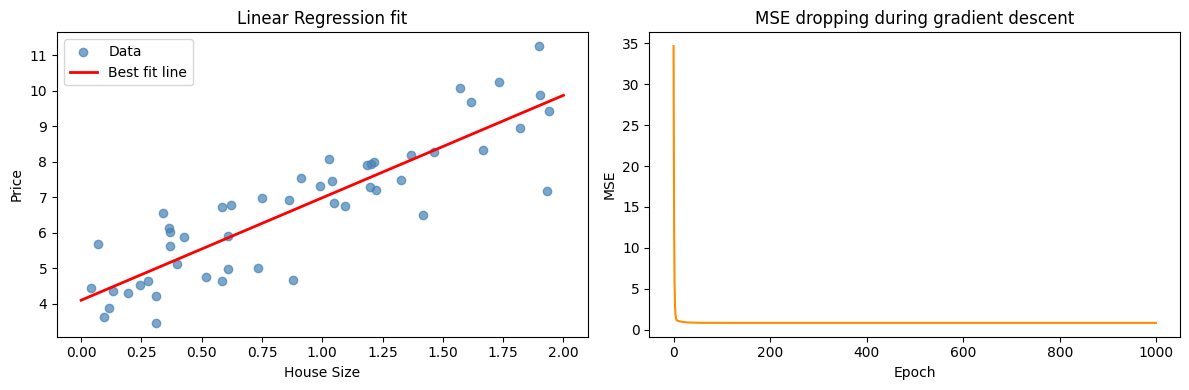

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Fake data: house size vs price ──────────────────────────────
np.random.seed(42)
X = 2 * np.random.rand(50)           # house sizes (arbitrary units)
y = 4 + 3 * X + np.random.randn(50)  # price = 4 + 3*size + noise

# ── 2. Add bias column (column of 1s for β₀) ──────────────────────
X_b = np.c_[np.ones((50, 1)), X]     # shape: (50, 2)

# ── 3. THE NORMAL EQUATION — finds perfect β in one shot ──────────
# β = (XᵀX)⁻¹ Xᵀy  ← closed-form solution (no looping needed)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f"β₀ (intercept) = {theta_best[0]:.4f}")   # should be ~4
print(f"β₁ (slope)     = {theta_best[1]:.4f}")   # should be ~3

# ── 4. Gradient Descent from scratch ──────────────────────────────
theta_gd = np.random.randn(2)   # start with random β₀ and β₁
alpha     = 0.1                 # learning rate
n         = len(X_b)
mse_history = []

for epoch in range(1000):
    predictions = X_b @ theta_gd
    errors      = predictions - y
    mse         = (errors ** 2).mean()
    mse_history.append(mse)
    gradients   = (2 / n) * X_b.T @ errors   # derivative of MSE
    theta_gd    -= alpha * gradients          # take a step downhill

print(f"\nAfter gradient descent:")
print(f"β₀ = {theta_gd[0]:.4f}")
print(f"β₁ = {theta_gd[1]:.4f}")

# ── 5. Plot: data + fitted line ────────────────────────────────────
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_pred = X_new_b @ theta_best

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color='steelblue', alpha=0.7, label='Data')
plt.plot(X_new, y_pred, 'r-', linewidth=2, label='Best fit line')
plt.xlabel('House Size'); plt.ylabel('Price')
plt.title('Linear Regression fit')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mse_history, color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('MSE dropping during gradient descent')

plt.tight_layout()
plt.show()

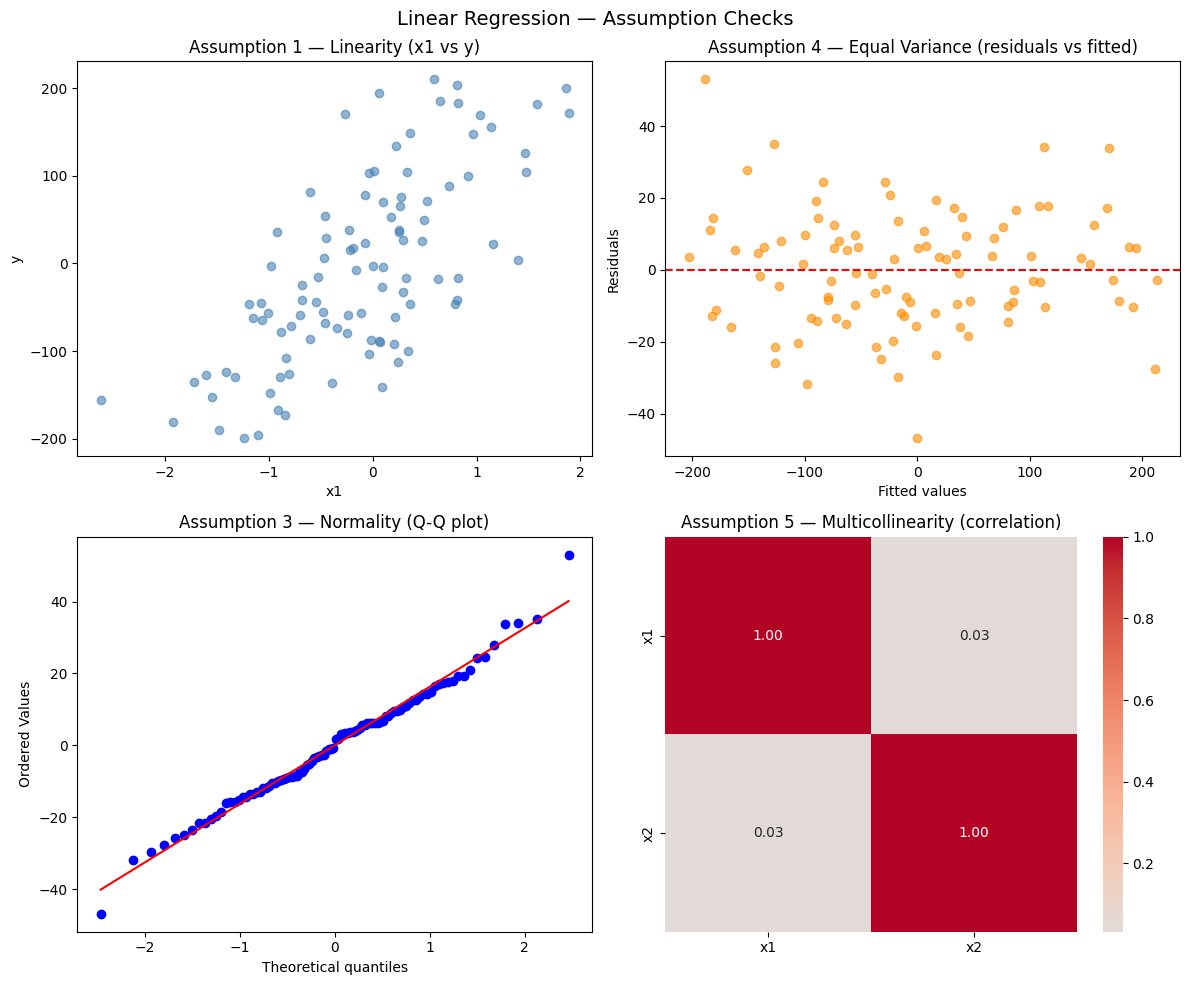


Assumption 2 — Independence:
Cannot be checked with a plot alone.
Ask: Is this time-series data? Are rows related to each other?
If yes → use Durbin-Watson test (covered in Phase 3)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import scipy.stats as stats

# ── Create sample data ─────────────────────────────────────────────
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=2,
                        noise=15, random_state=42)
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

# ── Fit the model ──────────────────────────────────────────────────
model = LinearRegression()
model.fit(df[['x1', 'x2']], df['y'])
y_pred    = model.predict(df[['x1', 'x2']])
residuals = df['y'] - y_pred

# ── Plot all 4 visual checks in one figure ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Linear Regression — Assumption Checks', fontsize=14)

# 1. Linearity: x1 vs y
axes[0, 0].scatter(df['x1'], df['y'], alpha=0.6, color='steelblue')
axes[0, 0].set_title('Assumption 1 — Linearity (x1 vs y)')
axes[0, 0].set_xlabel('x1'); axes[0, 0].set_ylabel('y')

# 2. Homoscedasticity: fitted vs residuals
axes[0, 1].scatter(y_pred, residuals, alpha=0.6, color='darkorange')
axes[0, 1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 1].set_title('Assumption 4 — Equal Variance (residuals vs fitted)')
axes[0, 1].set_xlabel('Fitted values'); axes[0, 1].set_ylabel('Residuals')

# 3. Normality: Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Assumption 3 — Normality (Q-Q plot)')

# 4. Multicollinearity: correlation heatmap
import seaborn as sns
corr = df[['x1', 'x2']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',
            center=0, ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Assumption 5 — Multicollinearity (correlation)')

plt.tight_layout()
plt.show()

# ── Assumption 2: Independence — print reminder ────────────────────
print("\nAssumption 2 — Independence:")
print("Cannot be checked with a plot alone.")
print("Ask: Is this time-series data? Are rows related to each other?")
print("If yes → use Durbin-Watson test (covered in Phase 3)")
# ```

# ---

# ## What to look for in each plot

# | Plot | Assumption met ✓ | Assumption violated ✗ |
# |---|---|---|
# | Scatter (x vs y) | Points follow a straight trend | Clear curve or U-shape |
# | Residuals vs fitted | Random cloud around zero | Fan shape or clear pattern |
# | Q-Q plot | Points hug the diagonal line | Points curve away at the ends |
# | Correlation heatmap | Values close to 0 between features | Values above 0.8 or below −0.8 |

# ---

## Thresholds to memorise
# ```
# Correlation between features  > 0.8  → multicollinearity problem
# Correlation between features  < 0.5  → you're safe
# Q-Q plot points               hugging the line → normality ok
# Residual plot                 any clear shape → homoscedasticity broken

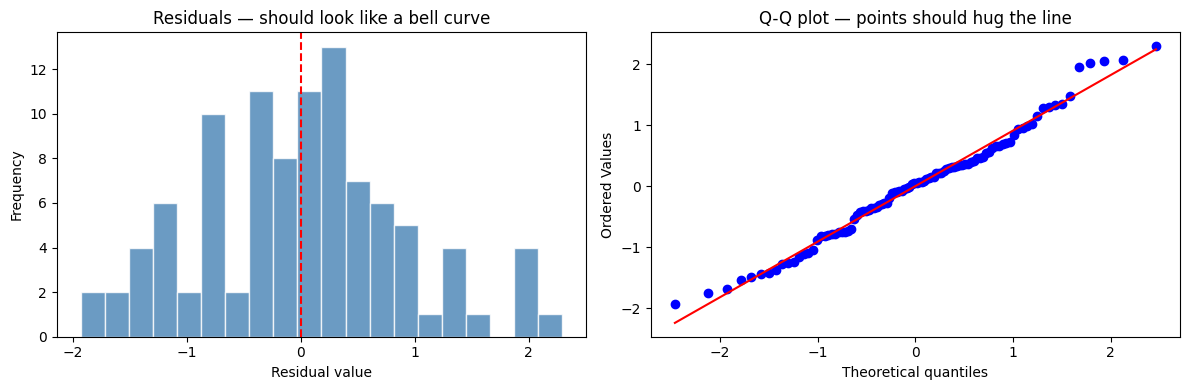


Shapiro-Wilk test
  Statistic : 0.9846
  p-value   : 0.2984
  Result → Normality assumption MET (p > 0.05)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# ── Data & model ───────────────────────────────────────────────────
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X.squeeze() + np.random.randn(100)  # normal errors

model = LinearRegression().fit(X, y)
y_pred    = model.predict(X)
residuals = y - y_pred            # ← these are what we test

# ── Visual check 1: Histogram of residuals ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=20, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Residuals — should look like a bell curve')
axes[0].set_xlabel('Residual value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)

# ── Visual check 2: Q-Q plot ───────────────────────────────────────
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot — points should hug the line')

plt.tight_layout()
plt.show()

# ── Statistical test: Shapiro-Wilk ────────────────────────────────
stat, p_value = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test")
print(f"  Statistic : {stat:.4f}")
print(f"  p-value   : {p_value:.4f}")

if p_value > 0.05:
    print("  Result → Normality assumption MET (p > 0.05)")
else:
    print("  Result → Normality assumption VIOLATED (p < 0.05)")
# ```

# ---

# ## The Shapiro-Wilk test — exact threshold

# This gives you a number instead of relying on your eyes:
# ```
# p-value > 0.05  →  residuals are normal         → assumption met ✓
# p-value < 0.05  →  residuals are NOT normal      → assumption violated ✗
# ```

# **If it fails — what to do:**
# ```
# Right skew in residuals   →  try log(y) or sqrt(y)
# Left skew in residuals    →  try squaring y
# Outliers causing S-shape  →  investigate and remove extreme outliers
# Still failing             →  switch to a non-linear model

LINEAR REGRESSION — FULL ASSUMPTION DIAGNOSTICS

[1] LINEARITY → Check scatter plots (x vs y)
    No single number — use your eyes on the plots below.

[2] INDEPENDENCE — Durbin-Watson
    DW statistic : 1.8488
    Result       : PASSED ✓ (between 1.5 and 2.5)

[3] NORMALITY — Shapiro-Wilk
    Statistic : 0.9946
    p-value   : 0.6853
    Result    : PASSED ✓ (p > 0.05)

[4] EQUAL VARIANCE — Breusch-Pagan
    Statistic : 11.6227
    p-value   : 0.0204
    Result    : FAILED ✗ (p < 0.05 — heteroscedastic)

[5] MULTICOLLINEARITY — VIF scores
Feature       VIF
     x1 10.155220
     x2  1.020240
     x3 10.190351
     x4  1.028751
    WARNING ✗ : x1 has VIF=10.2 — serious problem
    OK ✓      : x2 has VIF=1.0
    WARNING ✗ : x3 has VIF=10.2 — serious problem
    OK ✓      : x4 has VIF=1.0


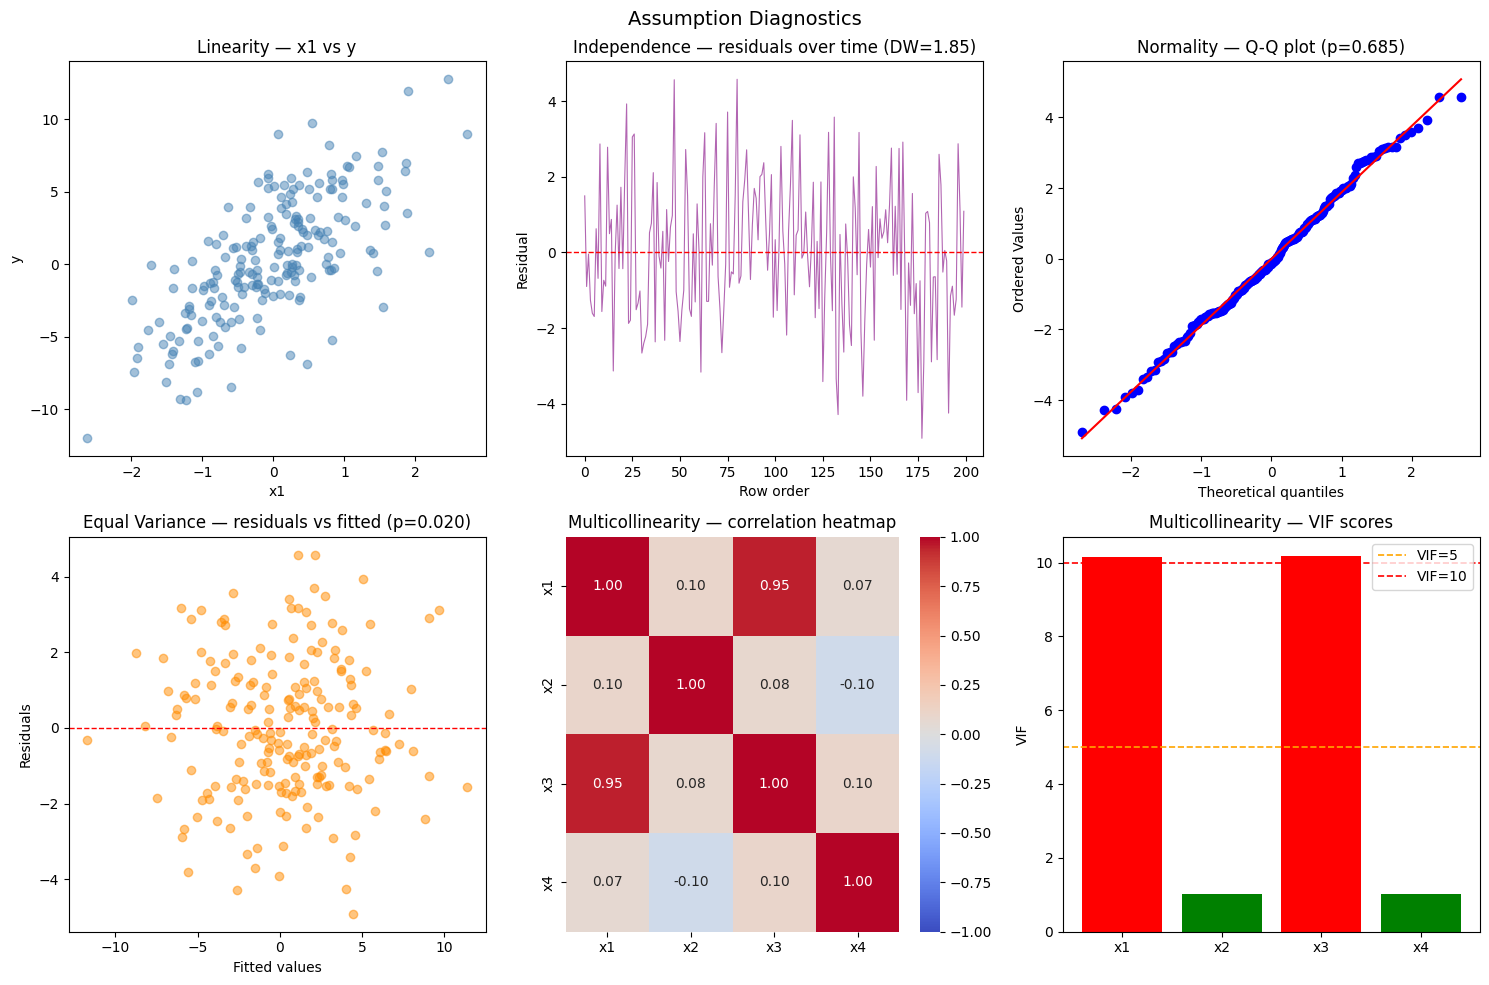

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

np.random.seed(42)

# ── Build a realistic dataset with 4 features ─────────────────────
n = 200
x1 = np.random.randn(n)
x2 = np.random.randn(n)
x3 = x1 + np.random.randn(n) * 0.3   # correlated with x1 → multicollinearity
x4 = np.random.randn(n)
y  = 3*x1 + 2*x2 + 1.5*x4 + np.random.randn(n) * 2

df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4, 'y': y})
features = ['x1', 'x2', 'x3', 'x4']
X = df[features]
y = df['y']

# ── Fit the model ──────────────────────────────────────────────────
model     = LinearRegression().fit(X, y)
y_pred    = model.predict(X)
residuals = y - y_pred

print("=" * 55)
print("LINEAR REGRESSION — FULL ASSUMPTION DIAGNOSTICS")
print("=" * 55)

# ─────────────────────────────────────────────────────────────────
# ASSUMPTION 1 — LINEARITY
# Visual only: scatter each feature vs y
# ─────────────────────────────────────────────────────────────────
print("\n[1] LINEARITY → Check scatter plots (x vs y)")
print("    No single number — use your eyes on the plots below.")

# ─────────────────────────────────────────────────────────────────
# ASSUMPTION 2 — INDEPENDENCE (Durbin-Watson)
# ─────────────────────────────────────────────────────────────────
dw = durbin_watson(residuals)
print(f"\n[2] INDEPENDENCE — Durbin-Watson")
print(f"    DW statistic : {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("    Result       : PASSED ✓ (between 1.5 and 2.5)")
elif dw < 1.5:
    print("    Result       : FAILED ✗ — positive autocorrelation")
else:
    print("    Result       : FAILED ✗ — negative autocorrelation")

# ─────────────────────────────────────────────────────────────────
# ASSUMPTION 3 — NORMALITY (Shapiro-Wilk)
# ─────────────────────────────────────────────────────────────────
stat_sw, p_sw = stats.shapiro(residuals)
print(f"\n[3] NORMALITY — Shapiro-Wilk")
print(f"    Statistic : {stat_sw:.4f}")
print(f"    p-value   : {p_sw:.4f}")
if p_sw > 0.05:
    print("    Result    : PASSED ✓ (p > 0.05)")
else:
    print("    Result    : FAILED ✗ (p < 0.05)")

# ─────────────────────────────────────────────────────────────────
# ASSUMPTION 4 — EQUAL VARIANCE (Breusch-Pagan)
# ─────────────────────────────────────────────────────────────────
X_with_const  = sm.add_constant(X)
bp_stat, p_bp, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n[4] EQUAL VARIANCE — Breusch-Pagan")
print(f"    Statistic : {bp_stat:.4f}")
print(f"    p-value   : {p_bp:.4f}")
if p_bp > 0.05:
    print("    Result    : PASSED ✓ (p > 0.05 — homoscedastic)")
else:
    print("    Result    : FAILED ✗ (p < 0.05 — heteroscedastic)")

# ─────────────────────────────────────────────────────────────────
# ASSUMPTION 5 — MULTICOLLINEARITY (VIF)
# ─────────────────────────────────────────────────────────────────
print(f"\n[5] MULTICOLLINEARITY — VIF scores")
vif_data = pd.DataFrame()
vif_data['Feature'] = features
vif_data['VIF']     = [variance_inflation_factor(X.values, i)
                        for i in range(X.shape[1])]
print(vif_data.to_string(index=False))
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        print(f"    WARNING ✗ : {row['Feature']} has VIF={row['VIF']:.1f} — serious problem")
    elif row['VIF'] > 5:
        print(f"    CAUTION   : {row['Feature']} has VIF={row['VIF']:.1f} — moderate concern")
    else:
        print(f"    OK ✓      : {row['Feature']} has VIF={row['VIF']:.1f}")

# ─────────────────────────────────────────────────────────────────
# PLOTS — All visuals in one figure
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Assumption Diagnostics', fontsize=14)

# 1. Linearity: x1 vs y (do this for every feature)
axes[0,0].scatter(df['x1'], df['y'], alpha=0.5, color='steelblue')
axes[0,0].set_title('Linearity — x1 vs y')
axes[0,0].set_xlabel('x1'); axes[0,0].set_ylabel('y')

# 2. Independence: residuals vs row order
axes[0,1].plot(residuals.values, color='purple', alpha=0.6, linewidth=0.8)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title(f'Independence — residuals over time (DW={dw:.2f})')
axes[0,1].set_xlabel('Row order'); axes[0,1].set_ylabel('Residual')

# 3. Normality: Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title(f'Normality — Q-Q plot (p={p_sw:.3f})')

# 4. Equal variance: residuals vs fitted
axes[1,0].scatter(y_pred, residuals, alpha=0.5, color='darkorange')
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title(f'Equal Variance — residuals vs fitted (p={p_bp:.3f})')
axes[1,0].set_xlabel('Fitted values'); axes[1,0].set_ylabel('Residuals')

# 5. Multicollinearity: correlation heatmap
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',
            center=0, ax=axes[1,1], fmt='.2f', vmin=-1, vmax=1)
axes[1,1].set_title('Multicollinearity — correlation heatmap')

# 6. VIF bar chart
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red'
          for v in vif_data['VIF']]
axes[1,2].bar(vif_data['Feature'], vif_data['VIF'], color=colors)
axes[1,2].axhline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF=5')
axes[1,2].axhline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF=10')
axes[1,2].set_title('Multicollinearity — VIF scores')
axes[1,2].set_ylabel('VIF'); axes[1,2].legend()

plt.tight_layout()
plt.show()
# ```

# ---

# ## What to expect from the output

# Since `x3 = x1 + noise`, the VIF for x1 and x3 will be high — that's the planted multicollinearity. Everything else should pass. This is intentional so you can see what a real violation looks like in the numbers.
# ```
# [2] DW       →  near 2.0         — independence fine
# [3] Shapiro  →  p > 0.05         — normality fine
# [4] BP       →  p > 0.05         — equal variance fine
# [5] VIF x1   →  probably > 5     — WARNING: correlated with x3
#     VIF x3   →  probably > 5     — WARNING: correlated with x1
# ```

# ---

# ## The Decision Flow — what to do after running diagnostics
# ```
# Run diagnostics
#      │
#      ├── Any test FAILED?
#      │        │
#      │        ├── Linearity failed    → Phase 4: transform x or use polynomial
#      │        ├── Independence failed → Phase 4: add lag features or use time-series model
#      │        ├── Normality failed    → Phase 4: transform y (log/sqrt)
#      │        ├── Equal var. failed   → Phase 4: WLS or transform y
#      │        └── VIF > 10            → Phase 4: drop or combine features
#      │
#      └── All tests PASSED?
#               └── Proceed to Phase 5: model evaluation

# ```